In [2]:
!pip install matplotlib seaborn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 15.1 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Titanic Dataset - Exploratory Data Analysis
# MSDS 25050 - Tools & Techniques for Data Science
# Imaan Mufti

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('ggplot')
sns.set_palette("husl")

# Display all columns
pd.set_option('display.max_columns', 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load the dataset with correct path
df = pd.read_csv('../data/Titanic-Dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Number of passengers: {len(df)}")

# Display first few rows
df.head()

Dataset loaded successfully!
Shape: (891, 12)
Number of passengers: 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Comprehensive Dataset Overview
print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

print("\n" + "="*50)
print("DETAILED INFO:")
print("="*50)
df.info()

=== DATASET OVERVIEW ===
Dataset Shape: 891 rows, 12 columns
Memory Usage: 0.28 MB

DETAILED INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
print("=== STATISTICAL SUMMARY ===")
print(df.describe())

# Optional: Add categorical summary
print("\n=== CATEGORICAL VARIABLES ===")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].value_counts())

=== STATISTICAL SUMMARY ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

=== CATEGORICAL VARIABLES ===
Survived  Pclass  Sex 

In [9]:
# Data Type Conversion for better analysis
print("=== DATA TYPE CONVERSIONS ===")
print("Before conversion:")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].dtypes)

# Convert to categorical
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("\nAfter conversion:")
print(df[['Survived', 'Pclass', 'Sex', 'Embarked']].dtypes)

# Verify memory optimization
print(f"\nMemory after optimization: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")

=== DATA TYPE CONVERSIONS ===
Before conversion:
Survived     int64
Pclass       int64
Sex         object
Embarked    object
dtype: object

After conversion:
Survived    category
Pclass      category
Sex         category
Embarked    category
dtype: object

Memory after optimization: 0.18 MB


=== MISSING VALUES ANALYSIS ===
          Missing Count  Missing Percentage
Age                 177           19.865320
Cabin               687           77.104377
Embarked              2            0.224467


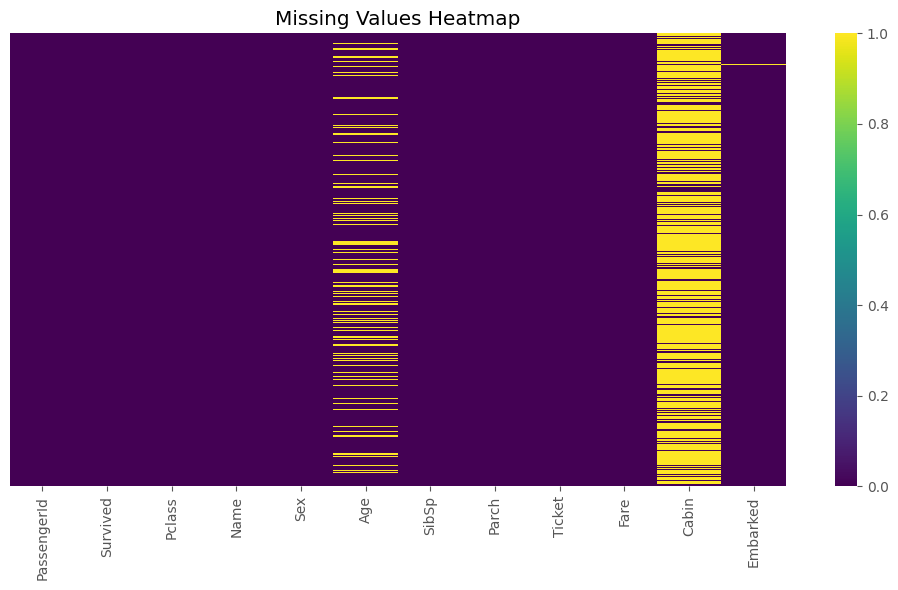

In [10]:
# Missing values analysis
print("=== MISSING VALUES ANALYSIS ===")
missing_data = df.isna().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [15]:
# Handle missing values - FIXED VERSION
print("=== HANDLING MISSING VALUES ===")

# Create a copy before imputation for comparison
df_clean = df.copy()

# 1. Handle Embarked (only 2 missing - use mode/most frequent)
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f"Embarked: Filled 2 missing values with '{embarked_mode}'")

# 2. Handle Age (significant missing - use median)
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
print(f"Age: Filled 177 missing values with median {age_median}")

# 3. Handle Cabin (too many missing - create indicator)
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype('category')
print(f"Cabin: Created 'Has_Cabin' indicator (True/False) instead of imputing")

# Verify all missing are handled (excluding Cabin which we intentionally left)
missing_excluding_cabin = df_clean.drop('Cabin', axis=1).isna().sum().sum()
print(f"\nRemaining missing values (excluding Cabin): {missing_excluding_cabin}")

print("\nUpdated missing values summary:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

=== HANDLING MISSING VALUES ===
Embarked: Filled 2 missing values with 'S'
Age: Filled 177 missing values with median 28.0
Cabin: Created 'Has_Cabin' indicator (True/False) instead of imputing

Remaining missing values (excluding Cabin): 0

Updated missing values summary:
Cabin    687
dtype: int64


In [18]:
# Check the CLEANED dataset, not the original
print("=== ORIGINAL DATASET (df) - STILL HAS MISSING VALUES ===")
print(df.isna().sum()[df.isna().sum() > 0])

print("\n=== CLEANED DATASET (df_clean) - MISSING VALUES HANDLED ===")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

=== ORIGINAL DATASET (df) - STILL HAS MISSING VALUES ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== CLEANED DATASET (df_clean) - MISSING VALUES HANDLED ===
Cabin    687
dtype: int64


In [20]:
# Feature Engineering - Create new meaningful features
print("=== FEATURE ENGINEERING ===")

# 1. Extract Title from Name
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(f"Titles extracted: {df_clean['Title'].value_counts().to_dict()}")

# 2. Create Family Size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 3. Create IsAlone feature
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype('category')

# 4. Create Age Groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 12, 18, 35, 60, 100], 
                              labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# 5. Create Fare Groups
df_clean['FareGroup'] = pd.qcut(df_clean['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

print(f"New features: Title, FamilySize, IsAlone, AgeGroup, FareGroup")
print(f"Updated shape: {df_clean.shape}")
df_clean[['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup']].head()

=== FEATURE ENGINEERING ===
Titles extracted: {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Dr': 7, 'Rev': 6, 'Mlle': 2, 'Major': 2, 'Col': 2, 'Countess': 1, 'Capt': 1, 'Ms': 1, 'Sir': 1, 'Lady': 1, 'Mme': 1, 'Don': 1, 'Jonkheer': 1}
New features: Title, FamilySize, IsAlone, AgeGroup, FareGroup
Updated shape: (891, 18)


,Title,FamilySize,IsAlone,AgeGroup,FareGroup
0,Mr,2,False,Adult,Low
1,Mrs,2,False,Middle,Very High
2,Miss,1,True,Adult,Medium
3,Mrs,2,False,Adult,Very High
4,Mr,1,True,Adult,Medium


In [21]:
# === SURVIVAL ANALYSIS WITH ENGINEERED FEATURES ===
print("=== COMPREHENSIVE SURVIVAL ANALYSIS ===")

# 1. Survival Rate by Title
print("\n1. SURVIVAL RATES BY TITLE:")
title_survival = pd.crosstab(df_clean['Title'], df_clean['Survived'], normalize='index') * 100
print(title_survival.round(1))

# 2. Survival Rate by Age Group  
print("\n2. SURVIVAL RATES BY AGE GROUP:")
age_survival = pd.crosstab(df_clean['AgeGroup'], df_clean['Survived'], normalize='index') * 100
print(age_survival.round(1))

# 3. Survival Rate by Family Size
print("\n3. SURVIVAL RATES BY FAMILY SIZE:")
family_survival = pd.crosstab(df_clean['FamilySize'], df_clean['Survived'], normalize='index') * 100
print(family_survival.round(1))

# 4. Survival Rate by IsAlone
print("\n4. SURVIVAL RATES BY ISALONE:")
alone_survival = pd.crosstab(df_clean['IsAlone'], df_clean['Survived'], normalize='index') * 100
print(alone_survival.round(1))

# 5. Survival Rate by Fare Group
print("\n5. SURVIVAL RATES BY FARE GROUP:")
fare_survival = pd.crosstab(df_clean['FareGroup'], df_clean['Survived'], normalize='index') * 100
print(fare_survival.round(1))

=== COMPREHENSIVE SURVIVAL ANALYSIS ===

1. SURVIVAL RATES BY TITLE:
Survived      0      1
Title                 
Capt      100.0    0.0
Col        50.0   50.0
Countess    0.0  100.0
Don       100.0    0.0
Dr         57.1   42.9
Jonkheer  100.0    0.0
Lady        0.0  100.0
Major      50.0   50.0
Master     42.5   57.5
Miss       30.2   69.8
Mlle        0.0  100.0
Mme         0.0  100.0
Mr         84.3   15.7
Mrs        20.8   79.2
Ms          0.0  100.0
Rev       100.0    0.0
Sir         0.0  100.0

2. SURVIVAL RATES BY AGE GROUP:
Survived     0     1
AgeGroup            
Child     42.0  58.0
Teen      57.1  42.9
Adult     64.7  35.3
Middle    60.0  40.0
Senior    77.3  22.7

3. SURVIVAL RATES BY FAMILY SIZE:
Survived        0     1
FamilySize             
1            69.6  30.4
2            44.7  55.3
3            42.2  57.8
4            27.6  72.4
5            80.0  20.0
6            86.4  13.6
7            66.7  33.3
8           100.0   0.0
11          100.0   0.0

4. SURVIVAL RA

=== CORRELATION ANALYSIS ===
Correlation with Survival:
Survived      1.000
Fare          0.257
Parch         0.082
FamilySize    0.017
SibSp        -0.035
Age          -0.065
Name: Survived, dtype: float64


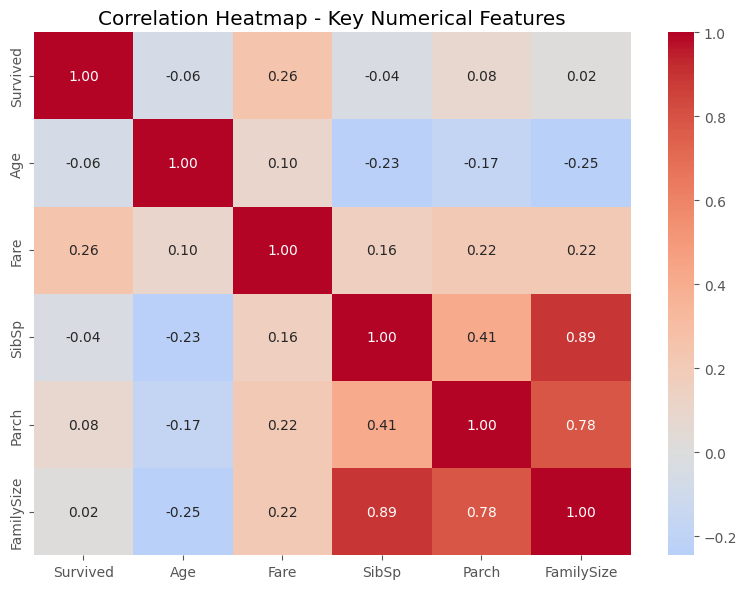

In [25]:
# === SIMPLE CORRELATION ANALYSIS ===
print("=== CORRELATION ANALYSIS ===")

# Select only key numerical features for correlation
simple_corr = df_clean[['Survived', 'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']].copy()

# Convert Survived to numeric
simple_corr['Survived'] = simple_corr['Survived'].cat.codes

# Calculate correlations
correlations = simple_corr.corr()['Survived'].sort_values(ascending=False)
print("Correlation with Survival:")
print(correlations.round(3))

# Create simple correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(simple_corr.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Key Numerical Features')
plt.tight_layout()
plt.show()